## Add available geomorphological information to the **Final Dataset** ##

In [1]:
import pandas as pd
import missingno
import sys

sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

c:\Users\dimit\AppData\Local\Programs\Python\Python39\lib\site-packages\geopandas\_compat.py:112: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  warnings.warn(


In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Attica'

In [4]:
MONTH = 'June'
PERIOD = '2nd'

In [5]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2023-{MONTH}-{PERIOD}.csv', encoding=enc)
geomorphological = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Geomorphological_filled.csv')
geomorphological.columns = geomorphological.columns.str.lower()

In [6]:
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case
0,23.65697,37.99220,2023-06-16,αττικης,αγιας βαρβαρας,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,2.4,26759.0,10925.9,44.75555,0.074774,-0.060750,-0.151611,0.060750,0.100399,-0.040473,-0.153980,0.040473,0.026880,0.020783,0.031232,0.020783,29.51,38.11,20.91,14.510000,8.020000,13.701111,6.297619,19.888462,11.006923,23.446923,12.160000,4.542834,4.542834,348.863664,124,0,0
1,23.82642,38.00806,2023-06-16,αττικης,αγιας παρασκευης,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,7.9,62157.0,7557.5,44.85879,0.200165,0.029318,-0.232135,-0.029318,0.161422,0.034817,-0.166628,-0.034817,0.052964,0.042617,0.060157,0.042617,NaN,37.27,NaN,13.528571,7.794000,15.082000,6.037273,18.770000,9.570000,21.901111,11.314000,8.524675,9.704345,423.912778,92,0,0
2,23.73031,37.93357,2023-06-16,αττικης,αγιου δημητριου,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,5.0,71747.0,14402.8,44.74465,0.102362,-0.031725,-0.170058,0.031725,0.088625,-0.030390,-0.146507,0.030390,0.027392,0.015634,0.044827,0.015634,29.23,36.99,21.47,14.659231,9.341000,13.997273,6.772609,20.618000,10.591250,24.562941,12.900000,7.849945,7.857991,364.222942,110,0,0
3,23.71341,38.04721,2023-06-16,αττικης,αγιων αναργυρων καματερου,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,9.2,61427.0,6833.8,44.83209,0.145408,-0.063574,-0.196932,0.063574,0.179769,-0.074228,-0.222959,0.074228,0.032292,0.012137,0.019477,0.012137,28.79,38.23,19.35,14.245000,7.601579,13.116000,6.119474,20.710000,9.976667,23.675000,11.323333,8.065397,8.858856,435.388974,122,0,0
4,23.34009,37.69503,2023-06-16,αττικης,αγκιστριου,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,13.4,1107.0,85.2,44.33593,0.320709,-0.056419,-0.261740,0.056419,0.336260,-0.037934,-0.277529,0.037934,0.033405,0.053971,0.017438,0.053971,20.95,22.41,19.49,14.222174,10.644444,12.956316,9.337778,15.516364,11.618000,17.763600,12.083333,10.224316,10.224316,483.147311,86,0,0


In [7]:
geomorphological.head()

,x,y,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,23.46396,37.33108,1426.812825,9526.118856,24,50.314461,387.046710,184.247277,0.0,1.000000
1,23.47454,37.73169,1901.598942,5182.958716,12,258.873851,229.509683,196.039884,0.0,1.812562
2,23.49722,37.71372,2205.171204,3731.540147,25,207.589234,289.724049,176.975937,0.0,1.891786
3,23.51990,37.74966,1606.369095,2361.867631,31,254.408817,128.656796,180.511498,0.0,1.306699
4,23.72137,37.99391,6716.989270,1493.626330,2,212.539863,68.539566,184.962678,0.0,1.629068


In [8]:
distances, indicies = calculate_nearest_topological(dataset, geomorphological)

In [9]:
print(f'Min distance: {min(distances)}')
print(f'Max distance: {max(distances)}')

Min distance: 0.0
Max distance: 3.9952337143388092


In [10]:
df_geo = pd.DataFrame(columns=geomorphological.columns)

In [11]:
for index in indicies:
    df_geo = df_geo.append(geomorphological.iloc[[index]])

df_geo.drop(columns=['x', 'y'], inplace = True)
df_geo.reset_index(drop=True, inplace=True)

In [12]:
dataset = pd.concat([dataset, df_geo], axis=1, join = 'outer')

In [13]:
dataset.head()

,x,y,dt_placement,nuts2,lau1,day,month,week,year,day_sin,day_cos,month_sin,month_cos,week_sin,week_cos,area,population,population_density,eq_distance,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_1week,acc_rainfall_2week,acc_rainfall_jan,mosq_pred,mosq_previous,case,distance_to_coast,distance_to_river,slope_mean_1km,aspect_mean_200m,elevation_mean_1km,hillshade_mean_1km,fs_area_1km,flow_accu_200m
0,23.65697,37.99220,2023-06-16,αττικης,αγιας βαρβαρας,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,2.4,26759.0,10925.9,44.75555,0.074774,-0.060750,-0.151611,0.060750,0.100399,-0.040473,-0.153980,0.040473,0.026880,0.020783,0.031232,0.020783,29.51,38.11,20.91,14.510000,8.020000,13.701111,6.297619,19.888462,11.006923,23.446923,12.160000,4.542834,4.542834,348.863664,124,0,0,4986.234414,2455.349701,5,136.450508,101.355755,167.697476,0.000000,1.730851
1,23.82642,38.00806,2023-06-16,αττικης,αγιας παρασκευης,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,7.9,62157.0,7557.5,44.85879,0.200165,0.029318,-0.232135,-0.029318,0.161422,0.034817,-0.166628,-0.034817,0.052964,0.042617,0.060157,0.042617,NaN,37.27,NaN,13.528571,7.794000,15.082000,6.037273,18.770000,9.570000,21.901111,11.314000,8.524675,9.704345,423.912778,92,0,0,14419.406690,1186.404835,17,195.624294,247.122730,186.152654,0.000000,4.727984
2,23.73031,37.93357,2023-06-16,αττικης,αγιου δημητριου,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,5.0,71747.0,14402.8,44.74465,0.102362,-0.031725,-0.170058,0.031725,0.088625,-0.030390,-0.146507,0.030390,0.027392,0.015634,0.044827,0.015634,29.23,36.99,21.47,14.659231,9.341000,13.997273,6.772609,20.618000,10.591250,24.562941,12.900000,7.849945,7.857991,364.222942,110,0,0,3030.589205,923.760750,6,197.484591,76.843700,185.824323,0.000000,10.672627
3,23.71341,38.04721,2023-06-16,αττικης,αγιων αναργυρων καματερου,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,9.2,61427.0,6833.8,44.83209,0.145408,-0.063574,-0.196932,0.063574,0.179769,-0.074228,-0.222959,0.074228,0.032292,0.012137,0.019477,0.012137,28.79,38.23,19.35,14.245000,7.601579,13.116000,6.119474,20.710000,9.976667,23.675000,11.323333,8.065397,8.858856,435.388974,122,0,0,10104.114693,102.938851,2,185.470524,110.515124,178.698121,0.000000,247.581759
4,23.34009,37.69503,2023-06-16,αττικης,αγκιστριου,16,6,24,2023,-0.101168,-0.994869,1.224647e-16,-1.0,0.292057,-0.956401,13.4,1107.0,85.2,44.33593,0.320709,-0.056419,-0.261740,0.056419,0.336260,-0.037934,-0.277529,0.037934,0.033405,0.053971,0.017438,0.053971,20.95,22.41,19.49,14.222174,10.644444,12.956316,9.337778,15.516364,11.618000,17.763600,12.083333,10.224316,10.224316,483.147311,86,0,0,703.682089,16702.208116,8,264.649030,132.349467,189.350397,0.115955,1.705489


<AxesSubplot:>

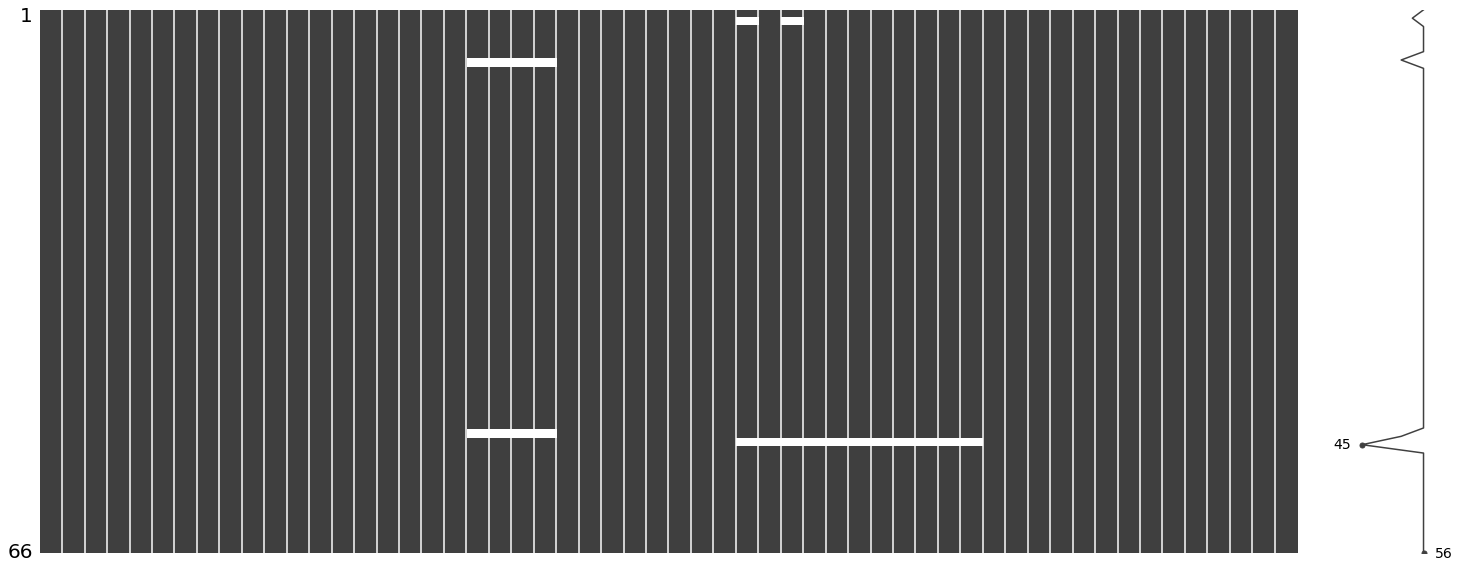

In [14]:
missingno.matrix(dataset)

In [15]:
cols = dataset.columns

In [16]:
cols

Index(['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month', 'week',
       'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin',
       'week_cos', 'area', 'population', 'population_density', 'eq_distance',
       'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean', 'ndwi_mean',
       'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std', 'ndbi_std', 'lst',
       'lst_day', 'lst_night', 'lst_jan_day_mean', 'lst_jan_night_mean',
       'lst_feb_day_mean', 'lst_feb_night_mean', 'lst_mar_day_mean',
       'lst_mar_night_mean', 'lst_apr_day_mean', 'lst_apr_night_mean',
       'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan',
       'mosq_pred', 'mosq_previous', 'case', 'distance_to_coast',
       'distance_to_river', 'slope_mean_1km', 'aspect_mean_200m',
       'elevation_mean_1km', 'hillshade_mean_1km', 'fs_area_1km',
       'flow_accu_200m'],
      dtype='object')

In [17]:
len(cols)

56

In [18]:
rearranged = ['x', 'y', 'dt_placement', 'nuts2', 'lau1', 'day', 'month',
       'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos',
       'week_sin', 'week_cos', 'area', 'population', 'population_density',
       'eq_distance', 'ndvi', 'ndmi', 'ndwi', 'ndbi', 'ndvi_mean', 'ndmi_mean',
       'ndwi_mean', 'ndbi_mean', 'ndvi_std', 'ndmi_std', 'ndwi_std',
       'ndbi_std', 'lst', 'lst_day', 'lst_night', 'lst_jan_day_mean',
       'lst_jan_night_mean', 'lst_feb_day_mean', 'lst_feb_night_mean',
       'lst_mar_day_mean', 'lst_mar_night_mean', 'lst_apr_day_mean',
       'lst_apr_night_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'distance_to_coast', 'distance_to_river', 'slope_mean_1km',
       'aspect_mean_200m', 'elevation_mean_1km', 'hillshade_mean_1km',
       'fs_area_1km', 'flow_accu_200m', 'mosq_pred', 'mosq_previous', 'case']

In [19]:
len(rearranged)

56

In [20]:
dataset = dataset[rearranged]

In [21]:
dataset.to_csv(f"../../data/{NUTS2}/{NUTS0}_{NUTS2}_WNV_Dataset_2023-{MONTH}-{PERIOD}.csv", encoding = enc, index = False)